# Gemma-2-2B-it 슬롯 추출 — v2_2 데이터셋 파인튜닝 (재실험)

**이 노트북이 하는 일**

[compare_finetune.ipynb](compare_finetune.ipynb) (v1_500) 와 동일한 절차를 **v2_2_500 데이터**로 재실행. 노트북 1개로 split / baseline 평가 / QLoRA 훈련 / adapter 평가 / 비교까지 처리한다.

1. **데이터 split (8:2)**: v2_2 CSV 500행 → seed=42 셔플 → 훈련 400 / held-out 100
2. **Baseline 평가**: raw `google/gemma-2-2b-it` 로 held-out 100 슬롯 추출
3. **QLoRA 훈련**: r=32, α=64, 5 epochs, lr=2e-4. **수동 label masking** (prompt → -100, collapse 방지)
4. **Adapter 평가**: 어댑터 attach → 같은 held-out 100 재평가
5. **비교**: pandas 표 + 막대그래프

**v1 노트북 대비 변경점**

| 항목 | v1 노트북 | 이 노트북 (v2) |
|---|---|---|
| 입력 CSV | `e2e_recommendation_eval_v1_500.csv` | `e2e_recommendation_eval_v2_2_500.csv` |
| split JSONL | `train_split.jsonl` / `eval_split.jsonl` | `train_split_v2_2.jsonl` / `eval_split_v2_2.jsonl` |
| 어댑터 경로 | `models/slot_extractor_gemma_adapter_v3/` | `models/slot_extractor_v2_2_adapter/` |
| 결과 JSON | `result_baseline_v3.json` / `result_adapter_v3.json` | `result_baseline_v2_2.json` / `result_adapter_v2_2.json` |
| 시스템 프롬프트 / LoRA / 하이퍼 / label masking | 동일 |

**v2_2 데이터 특이사항**
- 추가 컬럼: `gold_expected_cocktails`, `gold_allowed_categories`, `unlabelable_reason` — 슬롯 추출엔 무관, 무시
- 500행 중 **118행 (23.6%) 이 `unlabelable_reason` 표시됨** — 라벨 신뢰성 낮음 가능. 현재는 v1 노트북과 동일하게 **모두 포함**. 제외하려면 [§2 split 셀] 의 `EXCLUDE_UNLABELABLE = True`

**실행 환경**
- n18 GPU 노드 (V100-32GB) — `ssh n18` 후 `conda activate pba_env`
- conda env: **`pba_env`** (VS Code 우상단 커널 선택)
- `.env` 의 `HF_TOKEN` 필요 (gemma-2 gated)

**산출물**
- `tuning/data/train_split_v2_2.jsonl` (400) / `tuning/data/eval_split_v2_2.jsonl` (100)
- `models/slot_extractor_v2_2_adapter/` (LoRA 어댑터)
- `tuning/results/result_baseline_v2_2.json` / `tuning/results/result_adapter_v2_2.json`
- 노트북 하단 비교 표 + 막대그래프

**예상 소요**: 셋업 수 초 → baseline 평가 5~8분 → 훈련 15~25분 → adapter 평가 5~8분 → 비교 즉시 = **약 30~45분**

**제약**: 이 노트북은 `app/` 폴더를 **읽지도 않고 수정하지도 않음**. `scripts/` + `tuning/` + `models/` 만 사용.

In [1]:
import os, sys
# GPU0 은 다른 프로세스가 ~15GB 점유 중 → 비어있는 GPU1 강제 사용.
# 주의: 이미 이 커널에서 torch 를 import 했다면 CUDA_VISIBLE_DEVICES 변경이 반영되지 않을 수 있음.
torch_was_already_loaded = 'torch' in sys.modules
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
if torch_was_already_loaded:
    print('[경고] torch 가 이미 import 된 커널입니다. GPU 변경을 확실히 반영하려면 Kernel Restart 후 처음부터 다시 실행하세요.')

import torch

print("python:", sys.executable)
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"[{i}] {torch.cuda.get_device_name(i)}")
        x = torch.tensor([1.0, 2.0]).to(f"cuda:{i}")
        print(" test tensor device:", x.device)
    print("current device:", torch.cuda.current_device())
else:
    print("GPU not available in this notebook kernel.")


python: /home/ai_user/team_b2/miniconda3/envs/codus_env/bin/python
CUDA_VISIBLE_DEVICES: 1
torch: 2.5.1+cu121
cuda available: True
device count: 1
[0] Tesla V100-PCIE-32GB
 test tensor device: cuda:0
current device: 0


In [2]:
import sys, bitsandbytes as bnb
print(sys.executable)
print(bnb.__version__)


/home/ai_user/team_b2/miniconda3/envs/codus_env/bin/python
0.49.2


## 1. 셋업 — 경로 / GPU / HF token / SYSTEM_PROMPT

In [3]:
import os, sys, json, random, time, gc
from pathlib import Path

# cell 1 에서 먼저 잡는 것이 가장 안전하지만, 셀 단독 실행 케이스에서도 값은 맞춰 둔다.
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

ROOT = Path('/home/ai_user/team_b2/codus/PBA_AI_Project')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print('PROJECT ROOT :', ROOT)

import torch
print('CUDA_VISIBLE_DEVICES:', os.environ.get('CUDA_VISIBLE_DEVICES'))
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('torch current_device:', torch.cuda.current_device())
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f'  [{i}] {p.name}  {p.total_memory/1024**3:.1f} GB  cc={p.major}.{p.minor}')

HF_TOKEN = None
env_path = ROOT / '.env'
if env_path.exists():
    for line in env_path.read_text(encoding='utf-8').splitlines():
        if line.strip().startswith('HF_TOKEN='):
            HF_TOKEN = line.split('=', 1)[1].strip().strip('"').strip("'")
            os.environ['HF_TOKEN'] = HF_TOKEN
            os.environ['HUGGING_FACE_HUB_TOKEN'] = HF_TOKEN
            break
print('HF_TOKEN loaded:', bool(HF_TOKEN))

EVAL_CSV     = ROOT / 'data' / 'eval' / 'e2e_recommendation_eval_v2_2_500.csv'
BASE_MODEL   = 'google/gemma-2-2b-it'
TUNING_DIR   = ROOT / 'tuning'
DATA_DIR     = TUNING_DIR / 'data'
RESULTS_DIR  = TUNING_DIR / 'results'
ADAPTER_DIR  = ROOT / 'models' / 'slot_extractor_v2_2_adapter'
DATA_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_DIR.mkdir(exist_ok=True, parents=True)
print('EVAL_CSV exists :', EVAL_CSV.exists())
print('ADAPTER_DIR     :', ADAPTER_DIR)

SYSTEM_PROMPT = """너는 한국어 칵테일 취향 슬롯 추출기다. 발화에 명시된 정보만 JSON 으로 출력. 설명 금지.

스키마: {"extracted_slots": {...}}
- current_mood: "good"|"soso"|"bad"|null
- party_purpose: "celebration"|"date"|"business"|"solo"|"hangout"|null
- taste_profile: {"sweet"|"sour"|"bitter"|"body"|"creamy"|"freshness": "zero"|"low"|"medium"|"high"}
- aroma_profile: {"woody"|"minty"|"fruity"|"citrus"|"floral"|"coffee"|"herbal": "zero"|"low"|"medium"|"high"}
- strength_preference: "zero"|"light"|"medium"|"strong"|null
- disliked_bases: ["whiskey"|"gin"|"rum"|"vodka"|"tequila"]
- favorite_drinks: [str]

규칙:
1. 발화에 없는 축은 넣지 말 것.  2. 질문/"모르겠다" → {"extracted_slots":{}}.
3. "강하게"→high, "적당히"→medium, "살짝"→low, "싫어/빼줘"→zero.
4. taste: 단→sweet, 신→sour, 쓴→bitter, 바디→body, 크리미→creamy, 청량/상큼→freshness.
5. aroma: 우디→woody, 민트→minty, 과일/프루티→fruity, 시트러스/레몬→citrus, 꽃→floral, 커피→coffee, 허브→herbal.
6. "강하게" 를 taste/aroma 값으로 쓰면 안 됨 → "high". strength_preference 에만 "strong" 허용.
7. party_purpose: 혼자→solo, 회식→business, 생일/축하→celebration, 데이트→date, 친구모임→hangout."""

print('SYSTEM_PROMPT len (chars):', len(SYSTEM_PROMPT))

PROJECT ROOT : /home/ai_user/team_b2/codus/PBA_AI_Project
CUDA_VISIBLE_DEVICES: 1
CUDA available : True
torch current_device: 0
  [0] Tesla V100-PCIE-32GB  31.7 GB  cc=7.0
HF_TOKEN loaded: True
EVAL_CSV exists : True
ADAPTER_DIR     : /home/ai_user/team_b2/codus/PBA_AI_Project/models/slot_extractor_v2_2_adapter
SYSTEM_PROMPT len (chars): 1005


## 2. 데이터 8:2 split — train 400 / eval 100

v2_2 CSV 500행 → seed=42 셔플 → 8:2 split → JSONL 두 파일.

**unlabelable 행 필터링 (선택)**: 아래 셀의 `EXCLUDE_UNLABELABLE = False` 를 `True` 로 바꾸면 `unlabelable_reason` 채워진 118행 제외하고 split. 현재는 v1 노트북 동일 (모두 포함).

In [4]:
import csv

EXCLUDE_UNLABELABLE = False  # ← True 로 바꾸면 라벨 신뢰성 낮은 118행 제외

def csv_row_to_gold_slots(row: dict) -> dict:
    """CSV 행의 gold_* 컬럼들을 합쳐 extracted_slots 로."""
    gold = {}
    for f in ['current_mood', 'party_purpose', 'strength_preference']:
        v = (row.get(f'gold_{f}') or '').strip()
        if v: gold[f] = v
    for f in ['taste_profile', 'aroma_profile']:
        raw = (row.get(f'gold_{f}') or '').strip()
        try: parsed = json.loads(raw) if raw else {}
        except json.JSONDecodeError: parsed = {}
        if parsed: gold[f] = parsed
    for f in ['disliked_bases', 'favorite_drinks']:
        raw = (row.get(f'gold_{f}') or '').strip()
        try: parsed = json.loads(raw) if raw else []
        except json.JSONDecodeError: parsed = []
        if parsed: gold[f] = parsed
    return gold

def build_sample(user_text: str, gold_slots: dict) -> dict:
    return {
        'messages': [
            {'role': 'system',    'content': SYSTEM_PROMPT},
            {'role': 'user',      'content': user_text},
            {'role': 'assistant', 'content': json.dumps({'extracted_slots': gold_slots}, ensure_ascii=False)},
        ]
    }

with open(EVAL_CSV, encoding='utf-8') as f:
    rows_all = list(csv.DictReader(f))
rows = [r for r in rows_all if (r.get('user_text') or '').strip()]
n_unlabel = sum(1 for r in rows if (r.get('unlabelable_reason') or '').strip())
print(f'CSV 총 {len(rows_all)}행 → user_text 채워진 {len(rows)}행')
print(f'  unlabelable_reason 표시: {n_unlabel}행')

if EXCLUDE_UNLABELABLE:
    rows = [r for r in rows if not (r.get('unlabelable_reason') or '').strip()]
    print(f'  → unlabelable 제외 후 {len(rows)}행 사용')

random.seed(42)
random.shuffle(rows)
SPLIT = 0.8
n_train = int(len(rows) * SPLIT)
train_rows = rows[:n_train]
eval_rows  = rows[n_train:]
print(f'train: {len(train_rows)}  eval(held-out): {len(eval_rows)}')

def save_jsonl(path: Path, rows: list):
    with open(path, 'w', encoding='utf-8') as f:
        for r in rows:
            sample = build_sample(r['user_text'].strip(), csv_row_to_gold_slots(r))
            f.write(json.dumps(sample, ensure_ascii=False) + '\n')

TRAIN_JSONL = DATA_DIR / 'train_split_v2_2.jsonl'
EVAL_JSONL  = DATA_DIR / 'eval_split_v2_2.jsonl'
save_jsonl(TRAIN_JSONL, train_rows)
save_jsonl(EVAL_JSONL,  eval_rows)
print('저장 →', TRAIN_JSONL.name, '/', EVAL_JSONL.name)

with open(TRAIN_JSONL, encoding='utf-8') as f:
    first = json.loads(f.readline())
print('\n[훈련 샘플 예시]')
print('user     :', first['messages'][1]['content'][:80], '...')
print('assistant:', first['messages'][2]['content'])

CSV 총 500행 → user_text 채워진 500행
  unlabelable_reason 표시: 118행
train: 400  eval(held-out): 100
저장 → train_split_v2_2.jsonl / eval_split_v2_2.jsonl

[훈련 샘플 예시]
user     : 부드러운 질감이 살짝 있으면 좋겠어요 바디감이 묵직했으면 좋겠어요 단맛은 과하지 않게 적당하면 좋겠어요 부담 없이 균형 잡힌 도수면 좋겠어요 꽃 ...
assistant: {"extracted_slots": {"party_purpose": "hangout", "strength_preference": "medium", "taste_profile": {"body": "high", "sweet": "medium", "creamy": "medium"}, "aroma_profile": {"floral": "low"}}}


## 3. 공용 함수 — 모델 로드 / 추론 / 지표

v1 노트북과 동일.

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

SCALAR_FIELDS = ['party_purpose', 'strength_preference', 'current_mood']
DICT_FIELDS   = ['taste_profile', 'aroma_profile']
LIST_FIELDS   = ['disliked_bases', 'favorite_drinks']

def load_gemma(adapter_path=None):
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type='nf4',
    )
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=HF_TOKEN)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, token=HF_TOKEN,
        quantization_config=bnb, device_map='auto',
    )
    if adapter_path is not None:
        from peft import PeftModel
        model = PeftModel.from_pretrained(model, str(adapter_path))
        print('✓ adapter attached:', adapter_path)
    model.eval()
    return model, tokenizer

def build_messages_for_infer(user_text: str):
    return [{'role': 'user', 'content': f'{SYSTEM_PROMPT}\n\n---\n\n{user_text}'}]

def hf_generate(model, tokenizer, user_text: str, max_new_tokens: int = 180) -> str:
    msgs = build_messages_for_infer(user_text)
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, temperature=1.0, top_p=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    gen = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return gen.strip()

def parse_slots(raw: str) -> dict:
    raw = raw.strip()
    start = raw.find('{')
    if start == -1: return {}
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        if ch == '{': depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                try:
                    obj = json.loads(raw[start:i+1])
                    return obj.get('extracted_slots', obj)
                except json.JSONDecodeError:
                    return {}
    return {}

def _dict_overlap(pred, gold):
    def items_set(d):
        return {(k, json.dumps(v, sort_keys=True, ensure_ascii=False)) for k, v in d.items()}
    ps, gs = items_set(pred), items_set(gold)
    tp = len(ps & gs); return tp, len(ps)-tp, len(gs)-tp

def _list_overlap(pred, gold):
    ps, gs = set(pred), set(gold); tp = len(ps & gs)
    return tp, len(ps)-tp, len(gs)-tp

def evaluate_sample(pred, gold):
    out = {}
    for f in SCALAR_FIELDS:
        p, g = pred.get(f), gold.get(f)
        out[f] = {'pred': p, 'gold': g, 'correct': p == g}
    for f in DICT_FIELDS:
        p, g = pred.get(f) or {}, gold.get(f) or {}
        tp, fp, fn = _dict_overlap(p, g)
        out[f] = {'tp': tp, 'fp': fp, 'fn': fn, 'exact': p == g}
    for f in LIST_FIELDS:
        p, g = pred.get(f) or [], gold.get(f) or []
        tp, fp, fn = _list_overlap(p, g)
        out[f] = {'tp': tp, 'fp': fp, 'fn': fn, 'exact': sorted(p) == sorted(g)}
    return out

def aggregate(sample_results):
    n = len(sample_results); agg = {}
    for f in SCALAR_FIELDS:
        hits  = sum(1 for r in sample_results if r[f]['gold'] is not None and r[f]['correct'])
        denom = sum(1 for r in sample_results if r[f]['gold'] is not None)
        agg[f] = {'acc': hits/denom if denom else None, 'hits': hits, 'denom': denom}
    for f in DICT_FIELDS + LIST_FIELDS:
        tp = sum(r[f]['tp'] for r in sample_results)
        fp = sum(r[f]['fp'] for r in sample_results)
        fn = sum(r[f]['fn'] for r in sample_results)
        exact = sum(1 for r in sample_results if r[f]['exact'])
        prec = tp/(tp+fp) if tp+fp else None
        rec  = tp/(tp+fn) if tp+fn else None
        f1   = 2*prec*rec/(prec+rec) if (prec is not None and rec is not None and (prec + rec) > 0) else (0.0 if prec == 0.0 or rec == 0.0 else None)
        agg[f] = {'exact_match': exact/n, 'precision': prec, 'recall': rec, 'f1': f1,
                  'tp': tp, 'fp': fp, 'fn': fn}
    return agg

def run_eval(model, tokenizer, eval_jsonl: Path, label: str, save_path: Path):
    with open(eval_jsonl, encoding='utf-8') as f:
        samples = [json.loads(l) for l in f if l.strip()]
    print(f'[eval-{label}] {len(samples)} 샘플 시작…')
    results = []; errors = 0; t0 = time.time()
    for i, s in enumerate(samples, 1):
        user_text = s['messages'][1]['content']
        gold = json.loads(s['messages'][2]['content']).get('extracted_slots', {})
        try:
            raw = hf_generate(model, tokenizer, user_text)
            pred = parse_slots(raw)
        except Exception as e:
            errors += 1; pred = {}
            print(f'  [{i}] 오류: {e}')
        results.append(evaluate_sample(pred, gold))
        if i % 25 == 0:
            dt = time.time() - t0
            print(f'  {i}/{len(samples)}  ({dt:.0f}s)')
    dt = time.time() - t0
    print(f'[eval-{label}] 완료: {dt:.1f}s  오류 {errors}개')
    result = {
        'label': label, 'base_model': BASE_MODEL, 'dataset': 'v2_2_500',
        'n': len(samples), 'errors': errors, 'elapsed_s': round(dt, 1),
        'aggregate': aggregate(results),
    }
    save_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'저장 → {save_path}')
    return result

## 4. Baseline 평가 — raw gemma-2-2b-it (held-out 100)

V100 에서 약 5~8분.

In [6]:
baseline_model, tokenizer = load_gemma(adapter_path=None)
baseline_result = run_eval(
    baseline_model, tokenizer, EVAL_JSONL,
    label='baseline_v2_2', save_path=RESULTS_DIR / 'result_baseline_v2_2.json'
)
print('baseline acc (party_purpose):', baseline_result['aggregate']['party_purpose']['acc'])
print('baseline f1  (taste_profile):', baseline_result['aggregate']['taste_profile']['f1'])

# 다음 셀에서 훈련 모델 따로 로드하니까 VRAM 비우기
del baseline_model
gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

[eval-baseline_v2_2] 100 샘플 시작…
  25/100  (220s)
  50/100  (451s)
  75/100  (667s)
  100/100  (878s)
[eval-baseline_v2_2] 완료: 878.2s  오류 0개
저장 → /home/ai_user/team_b2/codus/PBA_AI_Project/tuning/results/result_baseline_v2_2.json
baseline acc (party_purpose): 0.5217391304347826
baseline f1  (taste_profile): 0.27807486631016043


## 5. 파인튜닝 — QLoRA + 수동 label masking

**핵심**: prompt(system+user) 토큰의 `labels` 를 `-100` 으로 만들어 loss 에서 제외 → assistant JSON 응답만 학습. 이거 안 하면 collapse.

**하이퍼파라미터** (v1 노트북과 동일):
- LoRA r=32, alpha=64, dropout=0.05
- epochs=5, batch=4, grad_accum=4 (effective 16)
- lr=2e-4, warmup 0.1, grad clip 1.0, weight_decay 0.01

**예상 시간**: V100 에서 15~25분 (v2_2 제외 옵션 켜면 더 짧음)

In [7]:
# 훈련용 모델 로드 (4-bit base + LoRA) — peft 직접 사용, Unsloth/TRL 우회
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4', bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=HF_TOKEN)
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, token=HF_TOKEN,
    quantization_config=bnb, device_map='auto',
)
model = prepare_model_for_kbit_training(model)

lora_cfg = LoraConfig(
    r=32, lora_alpha=64, lora_dropout=0.05, bias='none', task_type='CAUSAL_LM',
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

trainable params: 41,533,440 || all params: 2,655,875,328 || trainable%: 1.5638


In [8]:
from datasets import Dataset

MAX_LEN = 1024

def tokenize_with_masked_labels(sample):
    msgs = sample['messages']
    if msgs and msgs[0].get('role') == 'system':
        sys_c = msgs[0]['content']
        rest  = msgs[1:]
        if rest and rest[0].get('role') == 'user':
            rest = [
                {'role': 'user', 'content': f"{sys_c}\n\n---\n\n{rest[0]['content']}"},
                *rest[1:],
            ]
        msgs = rest
    assert msgs[-1]['role'] == 'assistant'
    prompt_msgs = msgs[:-1]
    prompt_text = tokenizer.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)
    full_text   = tokenizer.apply_chat_template(msgs,        tokenize=False, add_generation_prompt=False)
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)['input_ids']
    full_ids   = tokenizer(full_text,   add_special_tokens=False)['input_ids']
    full_ids = full_ids[:MAX_LEN]
    n_prompt = min(len(prompt_ids), len(full_ids))
    labels = [-100] * n_prompt + full_ids[n_prompt:]
    return {
        'input_ids': full_ids,
        'attention_mask': [1] * len(full_ids),
        'labels': labels,
    }

with open(TRAIN_JSONL, encoding='utf-8') as f:
    train_samples = [json.loads(l) for l in f if l.strip()]
random.seed(43)
random.shuffle(train_samples)
n_val = max(1, len(train_samples) // 10)
val_samples   = train_samples[:n_val]
train_samples = train_samples[n_val:]
print(f'train={len(train_samples)}  val={len(val_samples)}')

train_ds = Dataset.from_list(train_samples).map(tokenize_with_masked_labels, remove_columns=['messages'])
val_ds   = Dataset.from_list(val_samples  ).map(tokenize_with_masked_labels, remove_columns=['messages'])

sample0 = train_ds[0]
print('첫 샘플 input_ids 길이:', len(sample0['input_ids']))
print('  labels 중 -100 비율:', sum(1 for x in sample0['labels'] if x == -100) / len(sample0['labels']))

train=360  val=40


Map:   0%|          | 0/360 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

첫 샘플 input_ids 길이: 614
  labels 중 -100 비율: 0.8843648208469055


In [9]:
# 훈련 실행 — transformers.Trainer 직접 사용
from transformers import Trainer, TrainingArguments, DataCollatorForSeq2Seq

training_args = TrainingArguments(
    output_dir=str(ADAPTER_DIR),
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    max_grad_norm=1.0,
    weight_decay=0.01,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    eval_strategy='steps',
    eval_steps=25,
    save_strategy='steps',
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    seed=42,
    report_to='none',
    remove_unused_columns=False,
)

collator = DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
)
trainer.train()

# 어댑터 저장
model.save_pretrained(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))
print('✓ 어댑터 저장:', ADAPTER_DIR)

# 다음 셀에서 adapter 평가용 모델 새로 로드할 거라 VRAM 비우기
del model, trainer
gc.collect(); torch.cuda.empty_cache()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/home/ai_user/team_b2/miniconda3/envs/codus_env/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
25,0.089344,0.070833
50,0.024795,0.041792
75,0.016379,0.025847
100,0.008659,0.023791
115,0.008380,0.023760


/home/ai_user/team_b2/miniconda3/envs/codus_env/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/ai_user/team_b2/miniconda3/envs/codus_env/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return 

✓ 어댑터 저장: /home/ai_user/team_b2/codus/PBA_AI_Project/models/slot_extractor_v2_2_adapter


## 6. Fine-tuned 평가 — 같은 held-out 100

V100 에서 약 5~8분.

In [10]:
adapter_model, tokenizer = load_gemma(adapter_path=ADAPTER_DIR)
adapter_result = run_eval(
    adapter_model, tokenizer, EVAL_JSONL,
    label='adapter_v2_2', save_path=RESULTS_DIR / 'result_adapter_v2_2.json'
)
print('adapter acc (party_purpose):', adapter_result['aggregate']['party_purpose']['acc'])
print('adapter f1  (taste_profile):', adapter_result['aggregate']['taste_profile']['f1'])

del adapter_model
gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

✓ adapter attached: /home/ai_user/team_b2/codus/PBA_AI_Project/models/slot_extractor_v2_2_adapter
[eval-adapter_v2_2] 100 샘플 시작…
  25/100  (153s)
  50/100  (315s)
  75/100  (469s)
  100/100  (620s)
[eval-adapter_v2_2] 완료: 619.5s  오류 0개
저장 → /home/ai_user/team_b2/codus/PBA_AI_Project/tuning/results/result_adapter_v2_2.json
adapter acc (party_purpose): 1.0
adapter f1  (taste_profile): 1.0


## 7. 비교 — Pandas 표

In [11]:
import pandas as pd

def to_df(result, col_name):
    agg = result['aggregate']
    rows = []
    for f in SCALAR_FIELDS:
        rows.append({'field': f, 'metric': 'accuracy',    col_name: agg[f]['acc']})
    for f in DICT_FIELDS + LIST_FIELDS:
        rows.append({'field': f, 'metric': 'exact_match', col_name: agg[f]['exact_match']})
        rows.append({'field': f, 'metric': 'f1',          col_name: agg[f]['f1']})
    return pd.DataFrame(rows)

df = to_df(baseline_result, 'baseline').merge(
        to_df(adapter_result, 'finetuned'), on=['field', 'metric'])
df['delta_pp'] = (df['finetuned'] - df['baseline']) * 100

df_show = df.copy()
for c in ['baseline', 'finetuned']:
    df_show[c] = df_show[c].apply(lambda v: f'{v*100:.1f}%' if v is not None else '—')
df_show['delta_pp'] = df_show['delta_pp'].apply(lambda v: f'{v:+.1f}pp' if pd.notna(v) else '—')
display(df_show)

,field,metric,baseline,finetuned,delta_pp
0,party_purpose,accuracy,52.2%,100.0%,+47.8pp
1,strength_preference,accuracy,23.3%,100.0%,+76.7pp
2,current_mood,accuracy,42.0%,100.0%,+58.0pp
3,taste_profile,exact_match,0.0%,100.0%,+100.0pp
4,taste_profile,f1,27.8%,100.0%,+72.2pp
5,aroma_profile,exact_match,1.0%,100.0%,+99.0pp
6,aroma_profile,f1,20.0%,100.0%,+80.0pp
7,disliked_bases,exact_match,60.0%,99.0%,+39.0pp
8,disliked_bases,f1,41.1%,99.1%,+58.0pp
9,favorite_drinks,exact_match,85.0%,100.0%,+15.0pp


## 8. 비교 — 막대그래프

/tmp/ipykernel_3171206/1384087091.py:17: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3171206/1384087091.py:17: UserWarning: Glyph 47215 (\N{HANGUL SYLLABLE ROS}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3171206/1384087091.py:17: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3171206/1384087091.py:17: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3171206/1384087091.py:17: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3171206/1384087091.py:17: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3171206/1384087091.py:17: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}

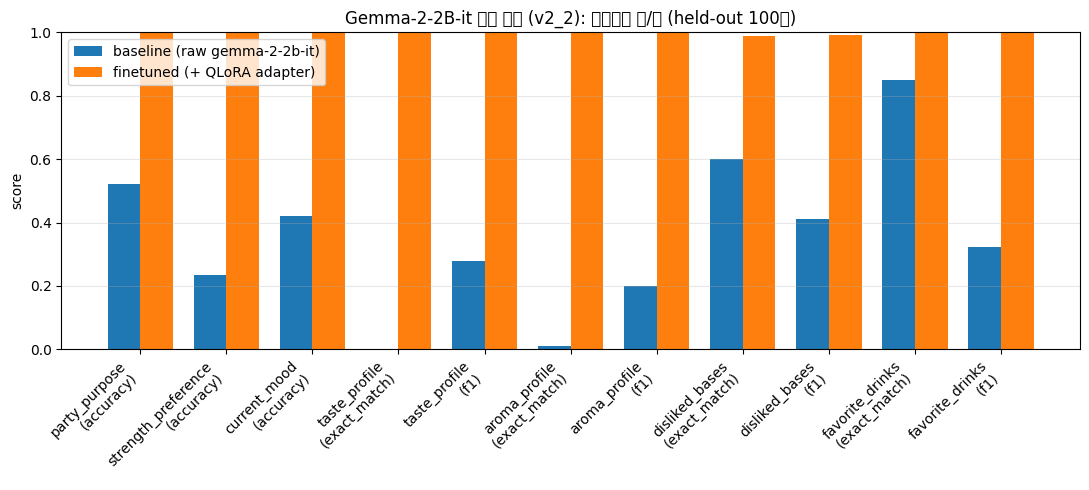

baseline  처리시간:  878.2s
finetuned 처리시간:  619.5s
baseline  오류: 0  /  finetuned 오류: 0


In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
labels = [f'{r.field}\n({r.metric})' for r in df.itertuples()]
x = range(len(labels))
w = 0.38
base_vals = [v if v is not None else 0 for v in df['baseline']]
ft_vals   = [v if v is not None else 0 for v in df['finetuned']]
ax.bar([i - w/2 for i in x], base_vals, width=w, label='baseline (raw gemma-2-2b-it)')
ax.bar([i + w/2 for i in x], ft_vals,   width=w, label='finetuned (+ QLoRA adapter)')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('score')
ax.set_ylim(0, 1.0)
ax.set_title(f'Gemma-2-2B-it 슬롯 추출 (v2_2): 파인튜닝 전/후 (held-out {baseline_result["n"]}개)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"baseline  처리시간: {baseline_result['elapsed_s']:>6.1f}s")
print(f"finetuned 처리시간: {adapter_result['elapsed_s']:>6.1f}s")
print(f"baseline  오류: {baseline_result['errors']}  /  finetuned 오류: {adapter_result['errors']}")

## 9. 팀원 인계용 요약

이 노트북 끝까지 실행하면 다음을 그대로 전달 가능:

- **Adapter path**: `models/slot_extractor_v2_2_adapter/`
- **Held-out 슬롯 지표**: 위 §7 표 (scalar acc / dict·list F1·exact)
- **결과 JSON**: `tuning/results/result_baseline_v2_2.json`, `tuning/results/result_adapter_v2_2.json`
- **데이터 split**: `tuning/data/train_split_v2_2.jsonl`, `tuning/data/eval_split_v2_2.jsonl` (재현 가능)

런타임 통합은 **다른 팀원이 처리**. 이 노트북은 어댑터 학습/평가만 담당. `app/` 폴더 일절 안 건드림.